# Setup

In [1]:
from data.cleaning import read_csv
from core import Config
import pandas as pd

config = Config()
TARGET = config.TARGET

static_df: pd.DataFrame = read_csv(
    config.selected_dir / "selected_static.csv",
    config.selected_dir / "selected_static_dtypes.csv",
    [0]
)

historic_df: pd.DataFrame = read_csv(
    config.selected_dir / "selected_historic.csv",
    config.selected_dir / "selected_historic_dtypes.csv",
    [0]
)

## Convert and Remove Features with constant values

In [2]:
# Filter and convert historic dataframe
# Detect columns with only boolean-like strings and convert dtype to boolean
def is_bool_string_col(series):
    bool_strings = [{'true', 'false'}, {'True', 'False'}, {'yes', 'no'}, {'Yes', 'No'}, {'1', '0'}]
    values = set(series.dropna().unique())
    return any(values <= s for s in bool_strings)


def transform_bool_strings(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    for col in df.select_dtypes(include=['object', 'string']):
        if is_bool_string_col(df[col]):
            df[col] = df[col].replace(
                {'true': True, 'True': True, 'yes': True, 'Yes': True, '1': True,
                 'false': False, 'False': False, 'no': False, 'No': False, '0': False}).astype('boolean')
            df[col] = df[col].astype('boolean')
    return df


def convert_to_categorical(dataframe: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = dataframe.copy()
    for col in columns:
        df[col] = df[col].astype('category')
    return df


# remove columns with only one unique (non‑NaN) value
def remove_constant_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    nunique = df.nunique(dropna=True)
    cols_to_drop = nunique[nunique == 1].index
    return df.drop(columns=cols_to_drop)


historic_df = transform_bool_strings(historic_df)

# Join static and historic dataframe to have GICS Sector Codes in the dataframe
all_df = historic_df.merge(
    static_df,
    on='Instrument',
    how='left'
)

all_df = convert_to_categorical(all_df, ['TR.GICSSubIndustryCode', 'TR.GICSIndustryCode', 'TR.GICSIndustryGroupCode',
                                         'TR.GICSSectorCode', 'Date'])
all_df = remove_constant_columns(all_df)

## Manuall Filter

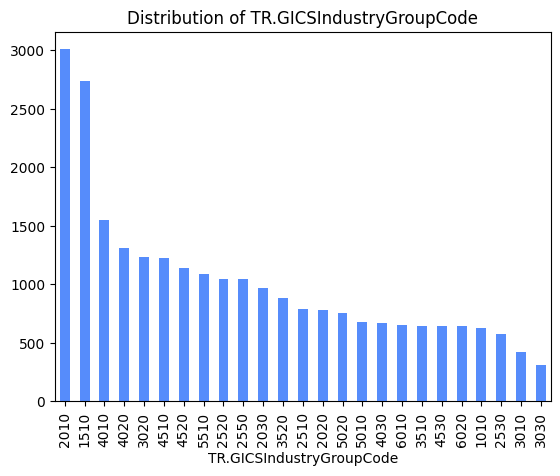

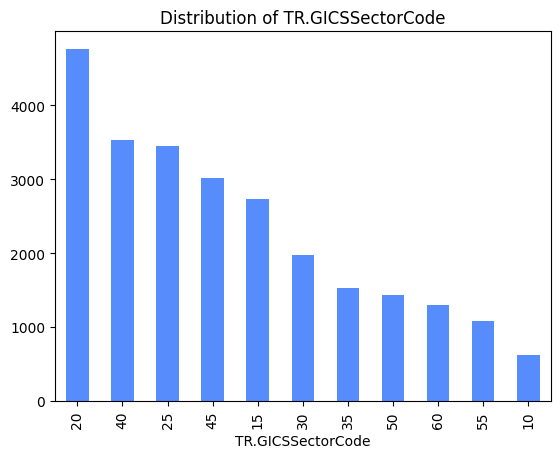

In [3]:
# Plot how the data is distributed the TR.GICSIndustryGroupCodes & TR.GICSSectorCodes
import matplotlib.pyplot as plt


def plot_industry_code_distribution(df: pd.DataFrame, industry_code_col: str) -> None:
    industry_code_counts = df[industry_code_col].value_counts()
    industry_code_counts.plot(kind='bar', title=f"Distribution of {industry_code_col}")
    plt.show()


plot_industry_code_distribution(all_df, "TR.GICSIndustryGroupCode")
plot_industry_code_distribution(all_df, "TR.GICSSectorCode")

# Data is distributed very heterogen. In IndustryGroup the fewest category has around 300 companies, whereas in Sector over 500.


In [4]:
# Manually remove redundant data
all_df.drop(
    [
        'TR.HeadquartersCountry',
        'TR.BusinessSector',
        'TR.TRBCActivity',
        'TR.TRBCIndustry',
        'TR.NAICSSector',
        'TR.NACEClassification',
        'TR.GICSSubIndustryCode',
        'TR.GICSIndustryCode',
        'TR.GICSIndustryGroupCode',
    ], axis=1, inplace=True)

# TR.COGSActValue & TR.F.COGSTot by definition, are relatively similar and at first glance seem to behave the same. TR.F.COGSTot has lower missingness.
# TR.GPMActValue & TR.F.GrossProfMarg by definition, are relatively similar. TR.F.GrossProfMarg has lower missingness.
# TR.GrossIncomeActValue & TR.F.GrossProfIndPropTot by definition, are relatively similar. TR.F.GrossProfIndPropTot has lower missingness.
# TR.CO2EquivalentEmissionIndirectScope2Locationbased has almost half of its values NA. And those values both report are almost the same.
# TR.HeadquartersCountry & TR.HQCountryCode are basically the same. More interesting would be in which countries a company is operating.
# TR.GICSIndustryCode is the main company differentiator. All others can be looked into if time allows.

# Create labeled DataFrame with row filtered emtpy Scope3.1
labeled_df: pd.DataFrame = all_df.dropna(subset=[TARGET])

# Analyse Scope 3.1 and Winzorise

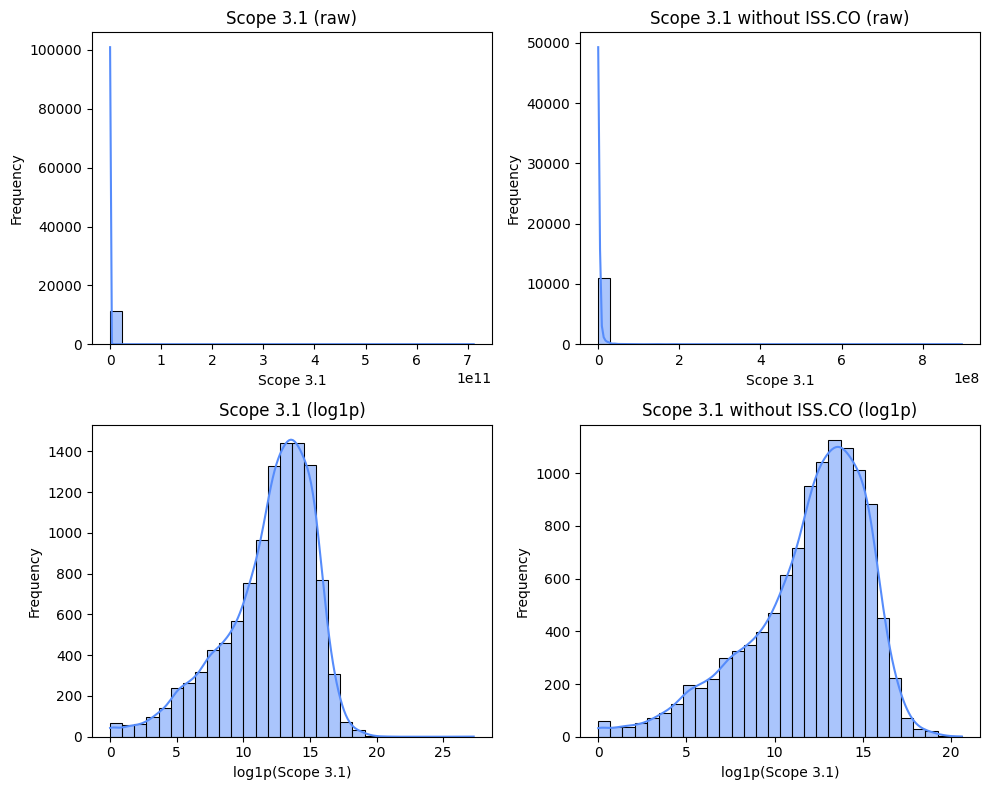

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze Scope 3.1 data
scope31_values: pd.Series = labeled_df[TARGET].dropna()

# TODO maybe remove ISS.CO because its values are so high. When winsorized on log scale, scope 3.1 is 0.01 higher and 4 more rows remain
no_iss_values: pd.Series = (
    labeled_df[~labeled_df['Instrument'].str.contains('ISS.CO')][TARGET].dropna()
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_raw, ax_no_iss_raw, ax_log, ax_no_iss_log = axes.ravel()

# Raw
sns.histplot(scope31_values, kde=True, bins=30, ax=ax_raw)
ax_raw.set_title("Scope 3.1 (raw)")
ax_raw.set_xlabel("Scope 3.1")
ax_raw.set_ylabel("Frequency")

# No ISS.CO raw
sns.histplot(no_iss_values, kde=True, bins=30, ax=ax_no_iss_raw)
ax_no_iss_raw.set_title("Scope 3.1 without ISS.CO (raw)")
ax_no_iss_raw.set_xlabel("Scope 3.1")
ax_no_iss_raw.set_ylabel("Frequency")

# Result is heavily skewed to the right
# log1p target value for normal distribution
scope31_values_log = pd.Series(np.log1p(scope31_values))
no_iss_values_log = pd.Series(np.log1p(no_iss_values))

# log1p
sns.histplot(scope31_values_log, kde=True, bins=30, ax=ax_log)
ax_log.set_title("Scope 3.1 (log1p)")
ax_log.set_xlabel("log1p(Scope 3.1)")
ax_log.set_ylabel("Frequency")

# No ISS.CO log1p
sns.histplot(no_iss_values_log, kde=True, bins=30, ax=ax_no_iss_log)
ax_no_iss_log.set_title("Scope 3.1 without ISS.CO (log1p)")
ax_no_iss_log.set_xlabel("log1p(Scope 3.1)")
ax_no_iss_log.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Winsorize

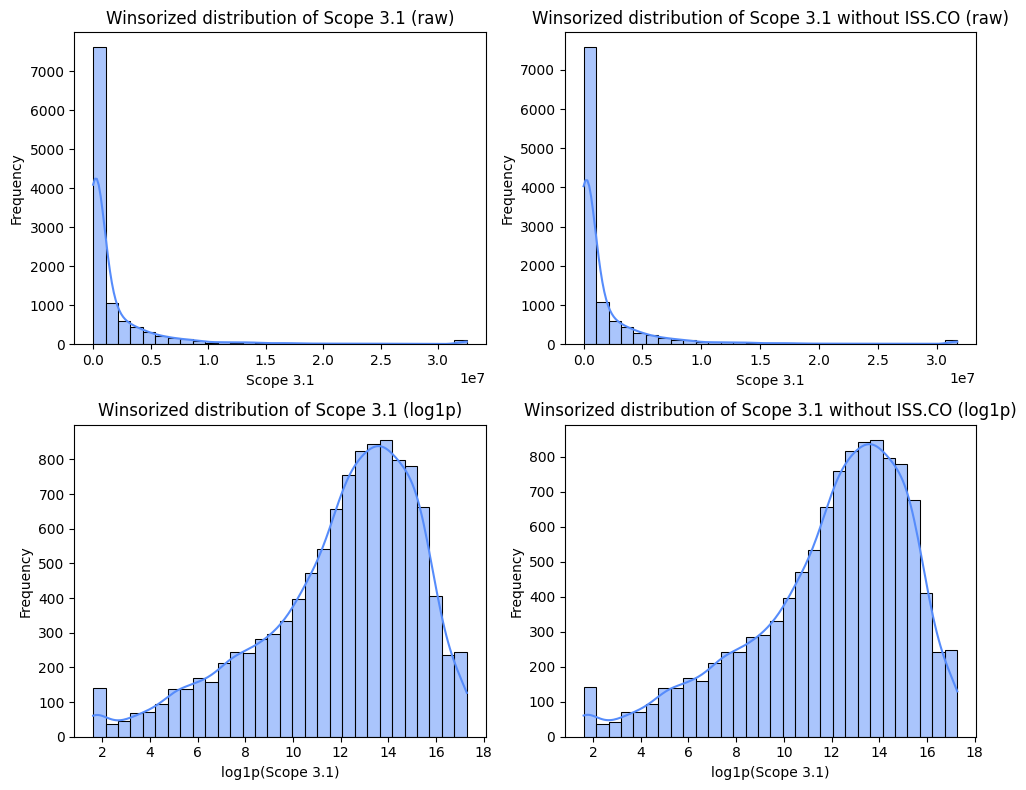

In [6]:
# Winsorize first and 99th quantile of column Scope 3.1
def winsorize_series(s: pd.Series, q_low=0.01, q_high=0.99) -> pd.Series:
    # s: 1D Series
    threshold_low, threshold_high = s.quantile([q_low, q_high])
    return s.clip(lower=threshold_low, upper=threshold_high)


winsorized: pd.Series = winsorize_series(scope31_values)
winsorized_no_iss: pd.Series = winsorize_series(no_iss_values)
winsorized_log: pd.Series = winsorize_series(scope31_values_log)
winsorized_no_iss_log: pd.Series = winsorize_series(no_iss_values_log)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_raw, ax_no_iss_raw, ax_log, ax_no_iss_log = axes.ravel()

# Raw
sns.histplot(winsorized, kde=True, bins=30, ax=ax_raw)
ax_raw.set_title("Winsorized distribution of Scope 3.1 (raw)")
ax_raw.set_xlabel("Scope 3.1")
ax_raw.set_ylabel("Frequency")

# No ISS.CO raw
sns.histplot(winsorized_no_iss, kde=True, bins=30, ax=ax_no_iss_raw)
ax_no_iss_raw.set_title("Winsorized distribution of Scope 3.1 without ISS.CO (raw)")
ax_no_iss_raw.set_xlabel("Scope 3.1")
ax_no_iss_raw.set_ylabel("Frequency")

# log1p
sns.histplot(winsorized_log, kde=True, bins=30, ax=ax_log)
ax_log.set_title("Winsorized distribution of Scope 3.1 (log1p)")
ax_log.set_xlabel("log1p(Scope 3.1)")
ax_log.set_ylabel("Frequency")

# No ISS.CO log1p
sns.histplot(winsorized_no_iss_log, kde=True, bins=30, ax=ax_no_iss_log)
ax_no_iss_log.set_title("Winsorized distribution of Scope 3.1 without ISS.CO (log1p)")
ax_no_iss_log.set_xlabel("log1p(Scope 3.1)")
ax_no_iss_log.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
# use Winsorize series to reduce labeled dataset
winsorized_labeled_df: pd.DataFrame = labeled_df.copy()
winsorized_labeled_df[TARGET] = winsorized

In [8]:
# free up variables
del scope31_values, no_iss_values, scope31_values_log, no_iss_values_log
del winsorized, winsorized_no_iss, winsorized_log, winsorized_no_iss_log
del fig, axes, ax_raw, ax_no_iss_raw, ax_log, ax_no_iss_log
del sns
del plt

# TODO winsorize all other features

# Outlier detection

# Missingness

In [9]:
# calculate missingness untouched labeled dataframe
def over_missingness(series: pd.Series, threshold=50) -> list:
    candidates: list[str] = series[series > threshold].index.tolist()
    return candidates


missing_counts: pd.Series = winsorized_labeled_df.isna().sum()
percent_missing_sum_method: pd.Series = (missing_counts / winsorized_labeled_df.shape[0]) * 100

# low missingness DataFrame
lm_df: pd.DataFrame = labeled_df.drop(over_missingness(percent_missing_sum_method), axis=1)

del missing_counts, percent_missing_sum_method, winsorized_labeled_df

## Redundancies

In [10]:
col_a = "TR.CO2EquivalentEmissionIndirectScope2Locationbased"
col_b = "TR.CO2IndirectScope2"

# Fill NA with 0 and compare elementwise
same_mask = (
        (lm_df[col_a] == lm_df[col_b]) |
        (lm_df[col_a].isna() & lm_df[col_b].isna())
)
same_count = same_mask.sum()

print(f"Same count: {same_count}")
print(f"Value count: {lm_df[col_a].notna().sum()}")
# TR.CO2EquivalentEmissionIndirectScope2Locationbased has almost half of its values NA. And those values both report are almost the same.
# Keeping TR.CO2IndirectScope2, cause it has lower missingness.

# low redundancies DataFrame
lr_df = lm_df.drop(col_a, axis=1)

del col_a, col_b, same_mask, same_count, lm_df

Same count: 6285
Value count: 6226


# Imputation
Imputation of categorical data isn't needed because remaining features (only TR.GICSSectorCode & TR.HQCountryCode) are complete.

In [11]:
from data.imputation import calculate_mode, calculate_median

imputed_df: pd.DataFrame = calculate_median(lr_df)
imputed_df = calculate_mode(imputed_df)
if imputed_df.isna().sum().sum() > 0:
    print(f"Imputation: {imputed_df.isna().sum().sum()} values are not Zero!!!")

# VIF Analysis

In [12]:
# convert all boolean columns in pandas dataframe to int
bool_cols = imputed_df.select_dtypes(include=['boolean']).columns
imputed_df[bool_cols] = imputed_df[bool_cols].astype('int')

del bool_cols

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
num_frame = imputed_df.select_dtypes(include=['number']).copy()
x = num_frame.to_numpy(dtype=np.float64)
vif_data["feature"] = num_frame.columns
vif_data["VIF"] = [variance_inflation_factor(x, i) for i in range(x.shape[1])]
vif_data = vif_data.sort_values(by="VIF")

del x, num_frame

vif_data

,feature,VIF
41,TR.PolicyEmissions,0.934538
32,TR.F.AcctRcvblTurnover,1.004757
50,TR.F.InvntTurnover,1.007121
33,TR.UpstreamScope3PurchasedGoodsAndServices,1.008079
44,TR.PolicyFairTrade,1.019951
49,TR.ClimateCommitment,1.025154
26,TR.NWCActValue,1.029508
16,TR.WasteTotal,1.031056
0,TR.WasteRecycledTotal,1.045931
42,TR.PolicyEnergyEfficiency,1.068184
